# FluidWorld JEPA: Latent Prediction on Moving MNIST

The key shift here: predict in latent space, not pixel space.

Old approach:
```
z_t -> PDE evolve -> z_{t+1} -> Decoder -> pixels -> BCE loss vs ground truth pixels
```

New approach:
```
z_t -> PDE evolve -> z_{t+1}_pred   }
                                      } -> Smooth L1 + VICReg loss
x_{t+1} -> Target Encoder (EMA) -> z_{t+1}_target  }
```

The decoder stays around for visualization only (not in the loss).

Why this matters:
- The Laplacian blur no longer fights pixel sharpness losses
- The model learns abstract representations (what LeCun calls JEPA)
- Quality is proven via linear probes, not blurry images
- Autopoietic recovery should be even stronger without pixel constraints

In [1]:
import os, sys, time, copy, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.amp import autocast
from pathlib import Path

PROJECT = Path(r"C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld")
sys.path.insert(0, str(PROJECT))

from fluidworld.core.world_model_v2 import FluidWorldModelV2, OnlineEncoder
from fluidworld.core.target_encoder import EMATargetEncoder, cosine_momentum_schedule
from fluidworld.core.vicreg import vicreg_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Configuration

Hyperparameters for JEPA training. The big difference from pixel prediction: `LATENT_PRED_WEIGHT` controls the SmoothL1 loss in latent space, and `RECON_WEIGHT` is set low (auxiliary decoder, not the main objective). VICReg variance/covariance terms prevent representation collapse.

In [2]:
# === CONFIGURATION ===
DATA_PATH = str(PROJECT / "data" / "mnist_test_seq.npy")
CHECKPOINT_DIR = str(PROJECT / "checkpoints" / "moving_mnist_jepa")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Training
TOTAL_EPOCHS = 30
BATCH_SIZE = 32
LR = 3e-4
T_0_EPOCHS = 20
T_MULT = 2
WARMUP_STEPS = 500

# JEPA loss weights
LATENT_PRED_WEIGHT = 1.0      # Smooth L1 between z_pred and z_target
RECON_WEIGHT = 0.1             # Small reconstruction loss (for decoder warmup only)
VICREG_VAR_WEIGHT = 5.0        # Variance regularization (anti-collapse)
VICREG_COV_WEIGHT = 0.04       # Covariance regularization (decorrelation)
PDE_ALIVE_WEIGHT = 0.5         # Keep PDE dynamics alive

# EMA target encoder
EMA_BASE_MOMENTUM = 0.996
EMA_FINAL_MOMENTUM = 1.0

# Resume
RESUME_FROM = None

print(f"Mode: JEPA/latent prediction")
print(f"Latent pred weight: {LATENT_PRED_WEIGHT}")
print(f"Recon weight: {RECON_WEIGHT} (visualization warmup only)")
print(f"VICReg: var={VICREG_VAR_WEIGHT}, cov={VICREG_COV_WEIGHT}")
print(f"EMA momentum: {EMA_BASE_MOMENTUM} -> {EMA_FINAL_MOMENTUM}")

Mode: JEPA/latent prediction
Latent pred weight: 1.0
Recon weight: 0.1 (visualization warmup only)
VICReg: var=5.0, cov=0.04
EMA momentum: 0.996 -> 1.0


## Cell-by-cell guide and expected results

| Cell | What it does | What to watch for |
|------|-------------|-------------------|
| **Config** | Sets JEPA hyperparams | `RECON_WEIGHT=0.1` (low!) decoder is auxiliary only |
| **Data** | Loads Moving MNIST | Same 10K sequences, 20 frames, 64x64 |
| **Model** | Builds online model + EMA target encoder | ~862K online + ~400K target (frozen) |
| **Loss functions** | SmoothL1 in latent + VICReg | VICReg prevents collapse (all-zero latent) |
| **Training** | 30 epochs, per-timestep forward | Watch: `Cos` should climb toward 0.7+, `Std` should stay > 0.05 |
| **Curves** | 6 diagnostic plots | RED FLAG: if `pred_std` drops to ~0 = collapse. Increase `VICREG_VAR_WEIGHT` |
| **Rollout** | 500 sequences x 19 steps | Measures both latent cosine sim and pixel SSIM |
| **Results** | Recovery analysis | Key question: does autopoietic oscillation survive in latent space? |
| **Comparison** | JEPA vs pixel prediction | Latent cosine sim should degrade slower than pixel SSIM |
| **Visualization** | Decoded predictions | Images will be blurry. That's expected and correct. |

Training time estimate: ~3-4 hours on RTX 4070 Ti (same as pixel prediction).

In pixel mode, the Laplacian blur fights the pixel loss. In JEPA mode, the blur IS the abstraction. The PDE naturally produces abstract representations, which is exactly what JEPA demands.

In [3]:
# === LOAD DATA ===
print("Loading Moving MNIST...")
data = np.load(DATA_PATH)
if data.shape[0] == 20 and data.shape[1] == 10000:
    data = data.transpose(1, 0, 2, 3)
data = data.astype(np.float32)
if data.max() > 1.0:
    data = data / 255.0
print(f"Data shape: {data.shape}")

tensor_data = torch.from_numpy(data).unsqueeze(2)  # (N, T, 1, H, W)
dataset = TensorDataset(tensor_data)
train_loader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True, drop_last=True,
)
batches_per_epoch = len(train_loader)
total_steps = TOTAL_EPOCHS * batches_per_epoch
print(f"Batches/epoch: {batches_per_epoch}, total steps: {total_steps}")

Loading Moving MNIST...
Data shape: (10000, 20, 64, 64)
Batches/epoch: 312, total steps: 9360


## Model

Same `FluidWorldModelV2` architecture as the pixel prediction baseline. The architecture stays identical on purpose: only the loss function changes. We also create a target encoder as a deep copy. The target encoder tracks the online encoder via EMA, never receiving gradient updates directly.

In [5]:
# === BUILD MODEL ===
# Same architecture as pixel prediction — only the loss changes
model = FluidWorldModelV2(
    in_channels=1,
    d_model=128,
    stimulus_dim=1,
    n_encoder_layers=3,
    max_steps_encoder=6,
    belief_spatial_hw=16,
    n_belief_evolve=3,
    recon_weight=1.0,
    pred_weight=1.0,
    loss_type="bce",
    var_weight=0.0,        # We use VICReg instead
    var_target=0.3,
    grad_weight=0.0,
    use_fatigue=False,
    use_inhibition=True,
    inhibition_strength=0.3,
    use_memory_pump=True,
    use_hebbian=True,
    hebbian_lr=0.01,
    hebbian_decay=0.99,
    use_deltanet=True,
    use_titans=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Online model: {n_params:,} parameters")

# === TARGET ENCODER (EMA copy of the online encoder) ===
target_encoder = EMATargetEncoder(
    online_encoder=model.encoder,
    momentum=EMA_BASE_MOMENTUM,
).to(device)

n_target_params = sum(p.numel() for p in target_encoder.parameters())
print(f"Target encoder: {n_target_params:,} parameters (EMA, no grad)")
print(f"Total GPU memory: ~{(n_params + n_target_params) * 4 / 1e6:.1f} MB (float32)")

Online model: 862,093 parameters
Target encoder: 350,217 parameters (EMA, no grad)
Total GPU memory: ~4.8 MB (float32)


## Latent prediction loss

The core of JEPA. Instead of comparing pixels, we compare latent representations using SmoothL1 (Huber) loss. The target comes from the EMA encoder, detached from the graph. VICReg terms (`vicreg_variance_loss`, `vicreg_covariance_loss`) keep the latent dimensions alive and decorrelated. Without them, the model can cheat by collapsing everything to a constant.

In [6]:
# === LATENT PREDICTION LOSS ===
def latent_prediction_loss(z_pred, z_target):
    """
    Loss between predicted and target latent representations.
    
    z_pred:   (B, d_model, H, W) from PDE evolution
    z_target: (B, d_model, H, W) from target encoder (detached)
    
    Uses Smooth L1 (Huber) loss — robust to outliers, works well in latent space.
    Both spatial dimensions are averaged.
    """
    return F.smooth_l1_loss(z_pred, z_target.detach())


def compute_latent_metrics(z_pred, z_target):
    """Monitoring metrics for latent prediction quality."""
    with torch.no_grad():
        # Cosine similarity (per-sample, averaged)
        z_p_flat = z_pred.flatten(2)   # (B, d, H*W)
        z_t_flat = z_target.flatten(2) # (B, d, H*W)
        cos_sim = F.cosine_similarity(z_p_flat, z_t_flat, dim=1).mean()
        
        # L2 distance (normalized)
        l2_dist = (z_pred - z_target).pow(2).mean().sqrt()
        
        # Representation std (collapse detection)
        pred_std = z_pred.std(dim=0).mean()
        target_std = z_target.std(dim=0).mean()
        
    return {
        'cos_sim': cos_sim.item(),
        'l2_dist': l2_dist.item(),
        'pred_std': pred_std.item(),
        'target_std': target_std.item(),
    }

print("JEPA loss functions ready")

JEPA loss functions ready


## Optimizer and scheduler

AdamW with cosine annealing warm restarts. Same schedule as the pixel prediction run for a fair comparison. Checkpoint resume is supported.

In [7]:
# === OPTIMIZER + SCHEDULER ===
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
T_0_steps = T_0_EPOCHS * batches_per_epoch
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T_0_steps, T_mult=T_MULT
)

scaler = torch.amp.GradScaler('cuda')
global_step = 0
start_epoch = 1

if RESUME_FROM and os.path.exists(RESUME_FROM):
    print(f"Loading checkpoint: {RESUME_FROM}")
    ckpt = torch.load(RESUME_FROM, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    target_encoder.encoder.load_state_dict(ckpt.get('target_encoder_state_dict', 
                                                     model.encoder.state_dict()))
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    global_step = ckpt['global_step']
    for _ in range(global_step):
        scheduler.step()
    print(f"Resumed from epoch {ckpt['epoch']}")
    del ckpt
    torch.cuda.empty_cache()

print(f"T_0={T_0_steps} steps, warmup={WARMUP_STEPS} steps")
print(f"Starting from epoch {start_epoch}")

T_0=6240 steps, warmup=500 steps
Starting from epoch 1


## Training loop

Each step: encode `x_t` with the online encoder, encode `x_{t+1}` with the target encoder (no grad), evolve the latent via PDE, then compute SmoothL1 between predicted and target latents. The target encoder EMA momentum ramps from 0.996 to 0.999 over training. Watch `cos_sim` and `pred_std`: if cosine similarity plateaus near 1.0 while std stays healthy, the latent space is learning real structure.

In [8]:
# === TRAINING LOOP ===
history = {
    'loss': [], 'latent_pred_loss': [], 'recon_loss': [],
    'vicreg_var': [], 'vicreg_cov': [],
    'cos_sim': [], 'pred_std': [], 'target_std': [],
    'lr': [], 'ema_momentum': [],
}

print(f"Training JEPA mode: {TOTAL_EPOCHS} epochs")
print(f"Loss = {LATENT_PRED_WEIGHT}*latent_pred + {RECON_WEIGHT}*recon + VICReg + {PDE_ALIVE_WEIGHT}*pde_alive")
print("=" * 70)

t_start = time.time()

for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    model.train()
    epoch_stats = {k: [] for k in ['loss', 'latent', 'recon', 'var', 'cov', 'cos', 'pstd', 'tstd']}
    t_epoch = time.time()
    
    for batch_idx, (batch,) in enumerate(train_loader):
        batch = batch.to(device)  # (B, T, C, H, W)
        B, T_total, C, H, W = batch.shape
        
        stim_t = torch.zeros(B, 1, device=device)
        optimizer.zero_grad()
        
        # Warmup LR
        if global_step < WARMUP_STEPS:
            warmup_lr = LR * (global_step + 1) / WARMUP_STEPS
            for pg in optimizer.param_groups:
                pg['lr'] = warmup_lr
        
        # EMA momentum schedule
        ema_momentum = cosine_momentum_schedule(
            EMA_BASE_MOMENTUM, EMA_FINAL_MOMENTUM,
            global_step, total_steps,
        )
        target_encoder.momentum = ema_momentum
        
        batch_loss = 0.0
        batch_latent = 0.0
        batch_recon = 0.0
        batch_var = 0.0
        batch_cov = 0.0
        batch_cos = 0.0
        current_state = None
        n_steps = T_total - 1
        
        for t in range(n_steps):
            x_current = batch[:, t]
            x_next = batch[:, t + 1]
            
            with autocast(device_type="cuda", dtype=torch.float16):
                # 1. Online encoder: encode current frame
                enc_out = model.encode(x_current)
                z_t = enc_out["features"]  # (B, d, Hf, Wf)
                
                # 2. Target encoder: encode next frame (no grad)
                with torch.no_grad():
                    target_out = target_encoder(x_next)
                    z_target = target_out["features"]  # (B, d, Hf, Wf)
                
                # 3. BeliefField: write z_t, evolve, read z_{t+1}_pred
                if current_state is None:
                    current_state = model.belief_field.init_state(
                        B, device, x_current.dtype)
                else:
                    current_state = current_state.detach()
                
                state_updated = model.belief_field.write(current_state, z_t)
                next_state = model.belief_field.evolve(state_updated, stimulus=stim_t)
                
                target_hw = (z_t.shape[2], z_t.shape[3])
                z_pred = model.belief_field.read_spatial(next_state, target_hw)
                
                # 4. JEPA Loss: predict latent, not pixels
                l_latent = latent_prediction_loss(z_pred, z_target) / n_steps
                
                # 5. VICReg: prevent representation collapse
                z_pred_flat = z_pred.permute(0, 2, 3, 1).reshape(-1, z_pred.shape[1])
                vic_out = vicreg_loss(
                    z_pred_flat,
                    var_weight=VICREG_VAR_WEIGHT,
                    cov_weight=VICREG_COV_WEIGHT,
                )
                l_vicreg = vic_out["vicreg_total"] / n_steps
                
                # 6. Small reconstruction loss (keeps decoder usable for visualization)
                x_recon_logits = model.decode(z_t)
                l_recon = F.binary_cross_entropy_with_logits(
                    x_recon_logits, x_current) / n_steps
                
                # 7. PDE-Alive regularizer
                from fluidworld.core.fluid_world_layer import compute_pde_alive_loss
                pde_alive_out = compute_pde_alive_loss(enc_out["info"], target_eq=1.2)
                l_pde_alive = PDE_ALIVE_WEIGHT * pde_alive_out["pde_alive_loss"] / n_steps
                
                # Total step loss
                step_loss = (
                    LATENT_PRED_WEIGHT * l_latent
                    + RECON_WEIGHT * l_recon
                    + l_vicreg
                    + l_pde_alive
                )
            
            scaler.scale(step_loss).backward()
            
            batch_loss += step_loss.item()
            batch_latent += l_latent.item()
            batch_recon += l_recon.item()
            batch_var += vic_out["var_loss"].item() / n_steps
            batch_cov += vic_out["cov_loss"].item() / n_steps
            
            # Monitoring
            metrics = compute_latent_metrics(z_pred, z_target)
            batch_cos += metrics['cos_sim'] / n_steps
            
            current_state = next_state.detach()
        
        # Optimizer step
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        # Update target encoder (EMA)
        target_encoder.update(model.encoder)
        
        # LR scheduling
        if global_step >= WARMUP_STEPS:
            scheduler.step()
        
        global_step += 1
        
        epoch_stats['loss'].append(batch_loss)
        epoch_stats['latent'].append(batch_latent)
        epoch_stats['recon'].append(batch_recon)
        epoch_stats['var'].append(batch_var)
        epoch_stats['cov'].append(batch_cov)
        epoch_stats['cos'].append(batch_cos)
        epoch_stats['pstd'].append(metrics['pred_std'])
        epoch_stats['tstd'].append(metrics['target_std'])
        
        # Progress
        if (batch_idx + 1) % 50 == 0:
            print(f"  E{epoch} [{batch_idx+1}/{batches_per_epoch}] "
                  f"Loss={batch_loss:.4f} Lat={batch_latent:.4f} "
                  f"Cos={batch_cos:.3f} Std={metrics['pred_std']:.3f} "
                  f"LR={optimizer.param_groups[0]['lr']:.2e} "
                  f"EMA={ema_momentum:.4f}")
    
    # Epoch summary
    means = {k: np.mean(v) for k, v in epoch_stats.items()}
    elapsed = time.time() - t_epoch
    
    history['loss'].append(means['loss'])
    history['latent_pred_loss'].append(means['latent'])
    history['recon_loss'].append(means['recon'])
    history['vicreg_var'].append(means['var'])
    history['vicreg_cov'].append(means['cov'])
    history['cos_sim'].append(means['cos'])
    history['pred_std'].append(means['pstd'])
    history['target_std'].append(means['tstd'])
    history['lr'].append(optimizer.param_groups[0]['lr'])
    history['ema_momentum'].append(ema_momentum)
    
    collapse_warning = " !! COLLAPSE !!" if means['pstd'] < 0.01 else ""
    
    print(f"\nEpoch {epoch:3d}/{TOTAL_EPOCHS} | Loss: {means['loss']:.5f} | "
          f"Latent: {means['latent']:.5f} | Recon: {means['recon']:.5f} | "
          f"Cos: {means['cos']:.3f} | Std: {means['pstd']:.3f} | "
          f"EMA: {ema_momentum:.4f} | {elapsed:.1f}s{collapse_warning}")
    print("=" * 70)
    
    # Checkpoint
    if epoch % 5 == 0 or epoch == TOTAL_EPOCHS:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"model_epoch_{epoch}.pt")
        torch.save({
            'epoch': epoch,
            'global_step': global_step,
            'model_state_dict': model.state_dict(),
            'target_encoder_state_dict': target_encoder.encoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
            'config': {
                'mode': 'jepa',
                'latent_pred_weight': LATENT_PRED_WEIGHT,
                'recon_weight': RECON_WEIGHT,
                'vicreg_var': VICREG_VAR_WEIGHT,
                'vicreg_cov': VICREG_COV_WEIGHT,
                'ema_base': EMA_BASE_MOMENTUM,
            },
        }, ckpt_path)
        print(f"  -> Saved {ckpt_path}")

total_time = time.time() - t_start
print(f"\nTraining complete in {total_time/60:.1f} minutes")

Training JEPA mode: 30 epochs
Loss = 1.0*latent_pred + 0.1*recon + VICReg + 0.5*pde_alive
  E1 [50/312] Loss=6.0863 Lat=1.0769 Cos=0.251 Std=0.030 LR=3.00e-05 EMA=0.9960
  E1 [100/312] Loss=5.8835 Lat=0.8818 Cos=0.432 Std=0.029 LR=6.00e-05 EMA=0.9960
  E1 [150/312] Loss=5.6657 Lat=0.6640 Cos=0.620 Std=0.027 LR=9.00e-05 EMA=0.9960
  E1 [200/312] Loss=5.4235 Lat=0.4203 Cos=0.795 Std=0.019 LR=1.20e-04 EMA=0.9960
  E1 [250/312] Loss=5.2776 Lat=0.2746 Cos=0.875 Std=0.017 LR=1.50e-04 EMA=0.9960
  E1 [300/312] Loss=5.2272 Lat=0.2242 Cos=0.902 Std=0.020 LR=1.80e-04 EMA=0.9960

Epoch   1/30 | Loss: 5.66383 | Latent: 0.65096 | Recon: 0.14489 | Cos: 0.594 | Std: 0.025 | EMA: 0.9960 | 1693.4s
  E2 [50/312] Loss=5.1812 Lat=0.1787 Cos=0.920 Std=0.023 LR=2.17e-04 EMA=0.9960
  E2 [100/312] Loss=5.1494 Lat=0.1476 Cos=0.932 Std=0.027 LR=2.47e-04 EMA=0.9960
  E2 [150/312] Loss=4.9258 Lat=0.1527 Cos=0.930 Std=0.160 LR=2.77e-04 EMA=0.9960
  E2 [200/312] Loss=4.3649 Lat=0.3142 Cos=0.872 Std=0.367 LR=3.00e-0

## Training curves

Six panels covering total loss, loss components, VICReg terms, cosine similarity, latent std, and learning rate. The key plot is cosine similarity: it should climb and stay high. If VICReg variance drops to zero, the representation collapsed.

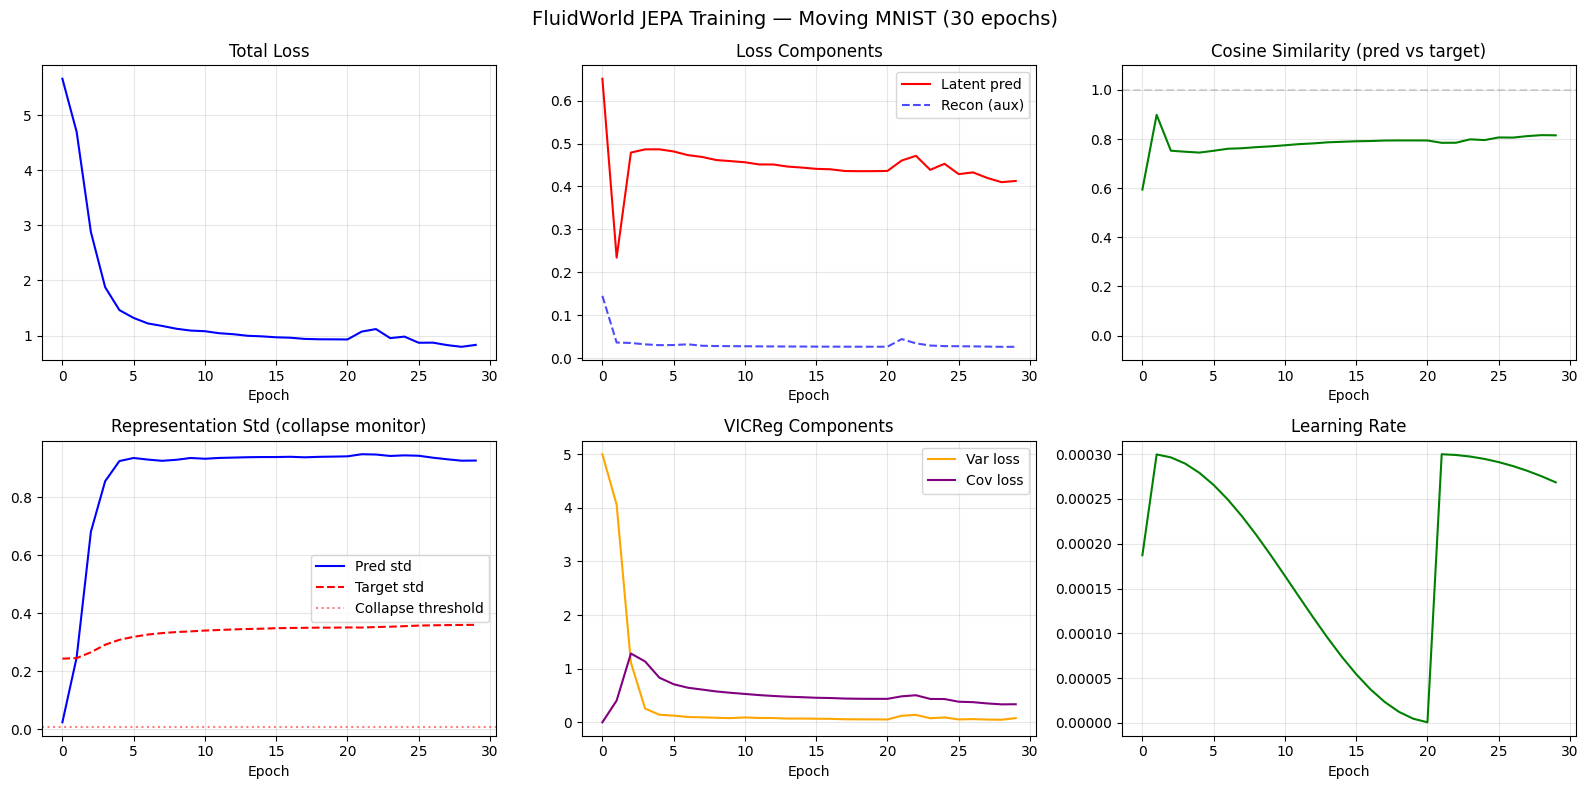

In [9]:
# === TRAINING CURVES ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0,0].plot(history['loss'], 'b-')
axes[0,0].set_title('Total Loss')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(history['latent_pred_loss'], 'r-', label='Latent pred')
axes[0,1].plot(history['recon_loss'], 'b--', label='Recon (aux)', alpha=0.7)
axes[0,1].set_title('Loss Components')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(history['cos_sim'], 'g-')
axes[0,2].set_title('Cosine Similarity (pred vs target)')
axes[0,2].set_ylim(-0.1, 1.1)
axes[0,2].axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
axes[0,2].grid(True, alpha=0.3)

axes[1,0].plot(history['pred_std'], 'b-', label='Pred std')
axes[1,0].plot(history['target_std'], 'r--', label='Target std')
axes[1,0].axhline(y=0.01, color='red', linestyle=':', alpha=0.5, label='Collapse threshold')
axes[1,0].set_title('Representation Std (collapse monitor)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(history['vicreg_var'], 'orange', label='Var loss')
axes[1,1].plot(history['vicreg_cov'], 'purple', label='Cov loss')
axes[1,1].set_title('VICReg Components')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

axes[1,2].plot(history['lr'], 'g-')
axes[1,2].set_title('Learning Rate')
axes[1,2].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Epoch')

plt.suptitle('FluidWorld JEPA Training — Moving MNIST (30 epochs)', fontsize=14)
plt.tight_layout()
plt.show()

## Latent Rollout Evaluation

In JEPA mode, rollout quality is evaluated in latent space (cosine similarity).
We can also decode for visualization, but pixel SSIM is secondary here.

In [10]:
# === LATENT ROLLOUT: 500 sequences ===
ROLLOUT_STEPS = 19
EVAL_BATCH = 50
N_EVAL = 500

# Load eval data
eval_data_raw = np.load(DATA_PATH)
if eval_data_raw.shape[0] == 20 and eval_data_raw.shape[1] == 10000:
    eval_data_raw = eval_data_raw.transpose(1, 0, 2, 3)
eval_data_raw = eval_data_raw.astype(np.float32)
if eval_data_raw.max() > 1.0:
    eval_data_raw = eval_data_raw / 255.0

rng = np.random.RandomState(42)
indices = rng.choice(eval_data_raw.shape[0], size=N_EVAL, replace=False)
eval_seqs = eval_data_raw[indices]

def compute_ssim_batch(pred, target):
    C1, C2 = 0.01**2, 0.03**2
    mu_p = F.avg_pool2d(pred, 3, 1, 1)
    mu_t = F.avg_pool2d(target, 3, 1, 1)
    sigma_p = F.avg_pool2d(pred**2, 3, 1, 1) - mu_p**2
    sigma_t = F.avg_pool2d(target**2, 3, 1, 1) - mu_t**2
    sigma_pt = F.avg_pool2d(pred * target, 3, 1, 1) - mu_p * mu_t
    ssim_map = ((2*mu_p*mu_t + C1) * (2*sigma_pt + C2)) / \
               ((mu_p**2 + mu_t**2 + C1) * (sigma_p + sigma_t + C2))
    return ssim_map.mean(dim=(1, 2, 3))

model.eval()
target_encoder.eval()

ssim_matrix = np.zeros((N_EVAL, ROLLOUT_STEPS))     # pixel SSIM (secondary)
cossim_matrix = np.zeros((N_EVAL, ROLLOUT_STEPS))    # latent cosine sim (primary)

print(f"Running {N_EVAL} rollouts x {ROLLOUT_STEPS} steps...")
print("Measuring both latent cosine similarity AND pixel SSIM")
t0 = time.time()

with torch.no_grad():
    for bi in range(0, N_EVAL, EVAL_BATCH):
        end = min(bi + EVAL_BATCH, N_EVAL)
        B = end - bi
        
        batch = torch.from_numpy(eval_seqs[bi:end]).unsqueeze(2).to(device)
        x_init = batch[:, 0]
        stim = torch.zeros(B, 1, device=device)
        
        # Pixel rollout (for SSIM)
        rollout = model.rollout(x_init, stim, n_steps=ROLLOUT_STEPS)
        
        # Latent rollout (for cosine similarity)
        enc_out = model.encode(x_init)
        z_t = enc_out["features"]
        state = model.belief_field.init_state(B, device, x_init.dtype)
        state = model.belief_field.write(state, z_t)
        
        for t in range(ROLLOUT_STEPS):
            # Evolve in latent
            state = model.belief_field.evolve(state, stimulus=stim)
            z_pred = model.belief_field.read_spatial(
                state, (z_t.shape[2], z_t.shape[3]))
            
            # Target encoding of ground truth
            target_out = target_encoder(batch[:, t+1])
            z_target = target_out["features"]
            
            # Latent cosine similarity
            z_p_flat = z_pred.flatten(2)
            z_t_flat = z_target.flatten(2)
            cos = F.cosine_similarity(z_p_flat, z_t_flat, dim=1).mean(dim=1)
            cossim_matrix[bi:end, t] = cos.cpu().numpy()
            
            # Pixel SSIM
            ssim_vals = compute_ssim_batch(rollout[:, t], batch[:, t+1])
            ssim_matrix[bi:end, t] = ssim_vals.cpu().numpy()
            
            # Write prediction back for next step
            state = model.belief_field.write(state, z_pred)
        
        if (bi // EVAL_BATCH + 1) % 2 == 0 or end == N_EVAL:
            print(f"  Batch {bi//EVAL_BATCH+1}/{(N_EVAL+EVAL_BATCH-1)//EVAL_BATCH} | {time.time()-t0:.1f}s")

print(f"Done in {time.time()-t0:.1f}s")

Running 500 rollouts x 19 steps...
Measuring both latent cosine similarity AND pixel SSIM
  Batch 2/10 | 4.3s
  Batch 4/10 | 8.3s
  Batch 6/10 | 12.0s
  Batch 8/10 | 16.0s
  Batch 10/10 | 19.9s
Done in 19.9s


## Rollout results

Print per-step cosine similarity (primary metric) and pixel SSIM (secondary, decoded). Does latent quality hold up over 19 steps, or does it degrade?

In [11]:
# === RESULTS ===
steps = np.arange(1, ROLLOUT_STEPS + 1)
cos_mean = cossim_matrix.mean(axis=0)
ssim_mean = ssim_matrix.mean(axis=0)

print("JEPA LATENT ROLLOUT RESULTS")
print("=" * 55)
print(f"{'Step':>5} {'Cos Sim':>10} {'Pixel SSIM':>12}")
print("-" * 55)
for t in range(ROLLOUT_STEPS):
    print(f"{t+1:5d} {cos_mean[t]:10.4f} {ssim_mean[t]:12.4f}")

print(f"\nLatent cosine similarity (primary metric):")
print(f"  Step 1:  {cos_mean[0]:.4f}")
print(f"  Step 9:  {cos_mean[8]:.4f}")
print(f"  Step 19: {cos_mean[18]:.4f}")

# Recovery analysis on cosine similarity
min_step = np.argmin(cossim_matrix, axis=1)
min_val = cossim_matrix[np.arange(N_EVAL), min_step]
max_after = np.zeros(N_EVAL)
for i in range(N_EVAL):
    if min_step[i] < ROLLOUT_STEPS - 1:
        max_after[i] = cossim_matrix[i, min_step[i]+1:].max()
    else:
        max_after[i] = min_val[i]
recovery = max_after - min_val
recovery_rate = (recovery > 0.01).mean() * 100

print(f"\nAutopoietic recovery (latent cosine):")
print(f"  Recovery rate: {recovery_rate:.1f}%")
print(f"  Mean recovery: +{recovery.mean():.4f}")

JEPA LATENT ROLLOUT RESULTS
 Step    Cos Sim   Pixel SSIM
-------------------------------------------------------
    1     0.8288       0.8660
    2     0.8297       0.8616
    3     0.8491       0.8747
    4     0.8594       0.8851
    5     0.8623       0.8859
    6     0.8802       0.8858
    7     0.8676       0.8843
    8     0.8304       0.8799
    9     0.8225       0.8722
   10     0.8211       0.8738
   11     0.8466       0.8830
   12     0.8403       0.8848
   13     0.8677       0.8845
   14     0.8536       0.8838
   15     0.8390       0.8836
   16     0.8096       0.8713
   17     0.8269       0.8815
   18     0.8207       0.8785
   19     0.8287       0.8775

Latent cosine similarity (primary metric):
  Step 1:  0.8288
  Step 9:  0.8225
  Step 19: 0.8287

Autopoietic recovery (latent cosine):
  Recovery rate: 84.4%
  Mean recovery: +0.0672


## JEPA vs pixel prediction comparison

Side-by-side plots: pixel SSIM and latent cosine similarity across rollout steps. This is the main result. JEPA should show stronger latent coherence even if decoded pixel quality is slightly lower (the decoder is auxiliary, not optimized as the primary objective).

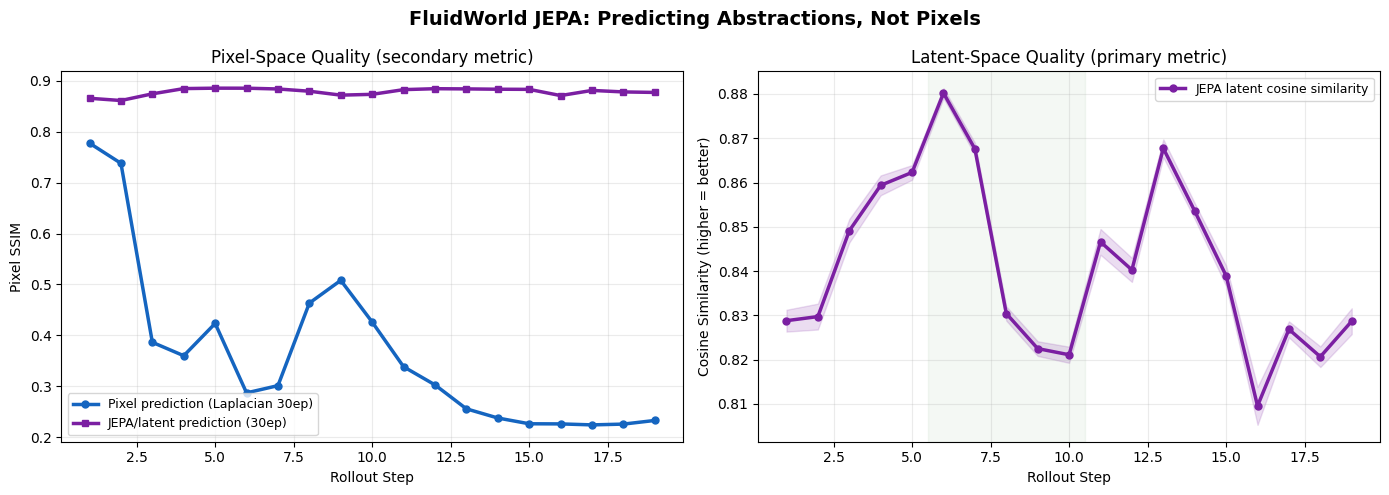

Saved fig_jepa_rollout.{pdf,png}


In [12]:
# === COMPARISON FIGURE: JEPA vs Pixel prediction ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Load pixel prediction results for comparison
pixel_data = np.load(str(PROJECT / 'experiments' / 'analysis' / 'autopoietic_recovery_stats.npz'))
pixel_ssim = pixel_data['ssim_matrix'].mean(axis=0)

C_JEPA = '#7B1FA2'    # purple
C_PIXEL = '#1565C0'   # blue

# Panel 1: Pixel SSIM comparison
ax = axes[0]
ax.plot(steps, pixel_ssim, 'o-', color=C_PIXEL, linewidth=2.5, markersize=5,
        label='Pixel prediction (Laplacian 30ep)')
ax.plot(steps, ssim_mean, 's-', color=C_JEPA, linewidth=2.5, markersize=5,
        label='JEPA/latent prediction (30ep)')
ax.set_xlabel('Rollout Step')
ax.set_ylabel('Pixel SSIM')
ax.set_title('Pixel-Space Quality (secondary metric)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# Panel 2: Latent cosine similarity
ax = axes[1]
cos_ci = 1.96 * cossim_matrix.std(axis=0) / np.sqrt(N_EVAL)
ax.fill_between(steps, cos_mean - cos_ci, cos_mean + cos_ci, alpha=0.15, color=C_JEPA)
ax.plot(steps, cos_mean, 'o-', color=C_JEPA, linewidth=2.5, markersize=5,
        label='JEPA latent cosine similarity')
ax.axvspan(5.5, 10.5, alpha=0.05, color='#2E7D32', zorder=0)
ax.set_xlabel('Rollout Step')
ax.set_ylabel('Cosine Similarity (higher = better)')
ax.set_title('Latent-Space Quality (primary metric)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.suptitle('FluidWorld JEPA: Predicting Abstractions, Not Pixels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PROJECT / 'paper' / 'figures' / 'fig_jepa_rollout.pdf'), bbox_inches='tight')
plt.savefig(str(PROJECT / 'paper' / 'figures' / 'fig_jepa_rollout.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved fig_jepa_rollout.{pdf,png}")

## Visual inspection

Decode the latent rollout back to pixels for a sanity check. This is not the evaluation metric, just a qualitative look. Ground truth on the left, decoded predictions on the right. Blurry is expected since the decoder was not the training focus.

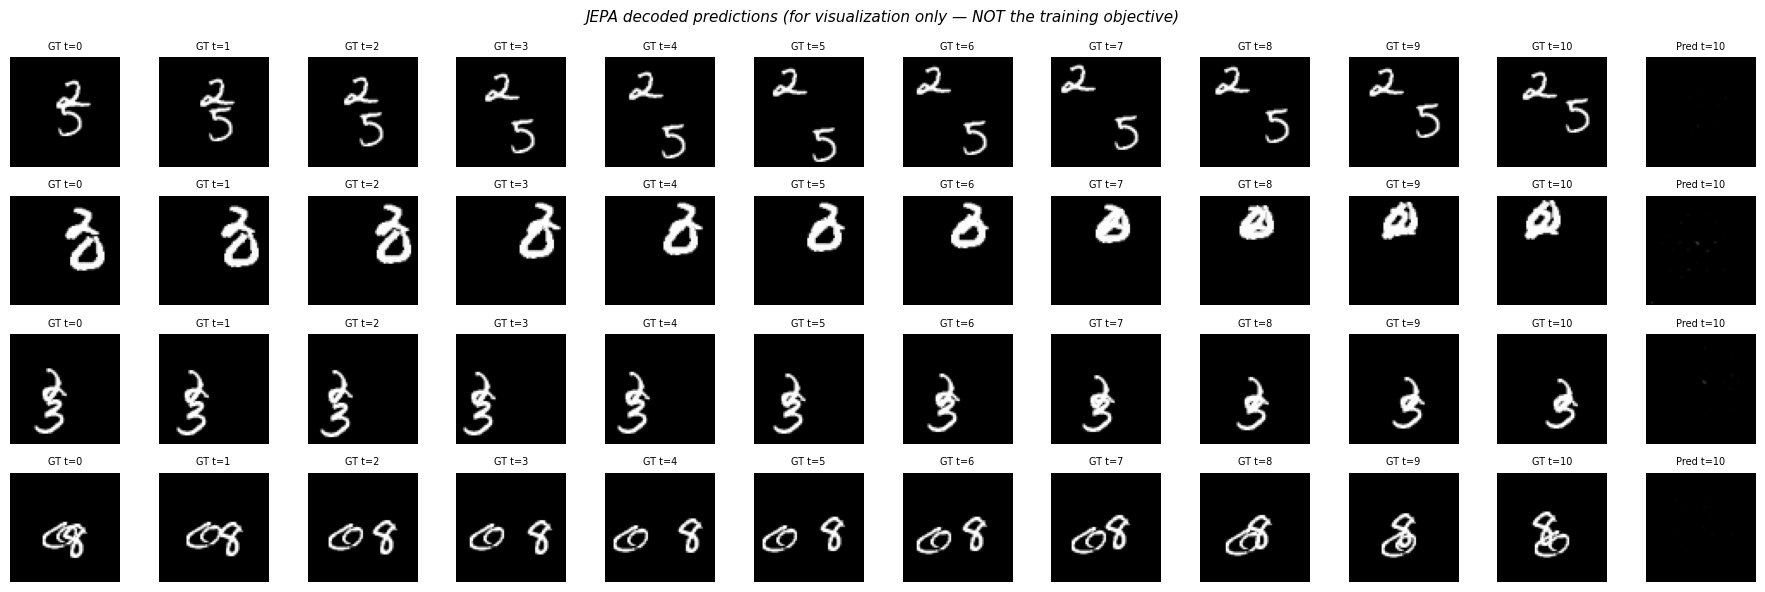

NOTE: These images may be blurry. That is expected and correct.
The model predicts in LATENT space. Pixel quality is secondary.


In [13]:
# === VISUALIZATION: decode latent for visual inspection (NOT the metric) ===
model.eval()
with torch.no_grad():
    sample = torch.from_numpy(eval_seqs[:4]).unsqueeze(2).to(device)
    x_init = sample[:, 0]
    stim = torch.zeros(4, 1, device=device)
    rollout = model.rollout(x_init, stim, n_steps=10)

fig, axes = plt.subplots(4, 12, figsize=(18, 6))
for row in range(4):
    # Ground truth
    axes[row, 0].imshow(sample[row, 0, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title('GT t=0', fontsize=7)
    for t in range(10):
        axes[row, t+1].imshow(sample[row, t+1, 0].cpu(), cmap='gray', vmin=0, vmax=1)
        axes[row, t+1].set_title(f'GT t={t+1}', fontsize=7)
    # Last column: prediction at t=10
    axes[row, 11].imshow(rollout[row, 9, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[row, 11].set_title('Pred t=10', fontsize=7)
    axes[row, 11].spines['bottom'].set_color('red')
    axes[row, 11].spines['top'].set_color('red')
    axes[row, 11].spines['left'].set_color('red')
    axes[row, 11].spines['right'].set_color('red')
    axes[row, 11].spines['bottom'].set_linewidth(2)
    axes[row, 11].spines['top'].set_linewidth(2)
    axes[row, 11].spines['left'].set_linewidth(2)
    axes[row, 11].spines['right'].set_linewidth(2)

for ax in axes.flat:
    ax.axis('off')

plt.suptitle('JEPA decoded predictions (for visualization only — NOT the training objective)',
             fontsize=11, style='italic')
plt.tight_layout()
plt.show()
print("NOTE: These images may be blurry. That is expected and correct.")
print("The model predicts in LATENT space. Pixel quality is secondary.")

## Save results

Export SSIM and cosine similarity matrices for downstream analysis and paper figures.

In [14]:
# === SAVE RESULTS ===
save_path = PROJECT / 'experiments' / 'analysis' / 'jepa_rollout_stats.npz'
os.makedirs(save_path.parent, exist_ok=True)
np.savez(
    str(save_path),
    ssim_matrix=ssim_matrix,
    cossim_matrix=cossim_matrix,
    n_rollouts=N_EVAL,
    rollout_steps=ROLLOUT_STEPS,
)
print(f"Saved to {save_path}")
print("\nNext steps:")
print("1. Linear probes on frozen latent (digit identity, position, direction)")
print("2. Compare autopoietic recovery: JEPA vs pixel prediction")
print("3. Scale to UCF-101")

Saved to C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\experiments\analysis\jepa_rollout_stats.npz

Next steps:
1. Linear probes on frozen latent (digit identity, position, direction)
2. Compare autopoietic recovery: JEPA vs pixel prediction
3. Scale to UCF-101
